# SmartCart — Part 1: Data Preprocessing

Load and clean interaction + product metadata, build a user–item matrix (missing ratings as 0), and aggregate behavior by user and category.


## 1. Load data

In [39]:
import pandas as pd
from pathlib import Path
from typing import cast


def resolve_data_dir() -> Path:
    for root in (Path.cwd(), *Path.cwd().parents):
        d = root / "data"
        if (d / "ecommerce_user_data.csv").exists() and (d / "product_details.csv").exists():
            return d
    raise FileNotFoundError(
        "Could not find data/ with ecommerce_user_data.csv and product_details.csv"
    )


DATA_DIR = resolve_data_dir()
user_data = cast(pd.DataFrame, pd.read_csv(DATA_DIR / "ecommerce_user_data.csv"))
product_data = cast(pd.DataFrame, pd.read_csv(DATA_DIR / "product_details.csv"))

print("Data directory:", DATA_DIR.resolve())
print("User interactions:", user_data.shape)
print("Products:", product_data.shape)
display(user_data.head())
display(product_data.head())

Data directory: C:\Users\Rahath\CursorProjects\SOEN-471-A2\data
User interactions: (724, 5)
Products: (100, 3)


,UserID,ProductID,Rating,Timestamp,Category
0,U000,P0009,5,2024-09-08,Books
1,U000,P0020,1,2024-09-02,Home
2,U000,P0012,4,2024-10-18,Books
3,U000,P0013,1,2024-09-18,Clothing
4,U000,P0070,4,2024-09-16,Toys


,ProductID,ProductName,Category
0,P0000,Toys Item 0,Clothing
1,P0001,Clothing Item 1,Electronics
2,P0002,Books Item 2,Electronics
3,P0003,Clothing Item 3,Electronics
4,P0004,Clothing Item 4,Electronics


## 2. Clean data

- Parse `Timestamp` to datetime  
- Drop rows with missing `UserID`, `ProductID`, or `Rating`  
- Restrict to products that exist in `product_details`  
- Resolve duplicate `(UserID, ProductID)` by keeping the latest interaction

In [40]:
user_data["Timestamp"] = pd.to_datetime(user_data["Timestamp"], errors="coerce")

before = len(user_data)
user_data = user_data.dropna(subset=["UserID", "ProductID", "Rating"]).copy()
valid_products = product_data["ProductID"].tolist()
user_data = user_data[user_data["ProductID"].isin(valid_products)]

user_data_sorted = cast(pd.DataFrame, pd.DataFrame.sort_values(cast(pd.DataFrame, user_data), by=["Timestamp"]))
user_data = cast(pd.DataFrame, user_data_sorted.drop_duplicates(
    subset=["UserID", "ProductID"], keep="last"
))

print(f"Rows before cleaning: {before}, after: {len(user_data)}")
user_data.info()

Rows before cleaning: 724, after: 724
<class 'pandas.DataFrame'>
Index: 724 entries, 464 to 247
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   UserID     724 non-null    str           
 1   ProductID  724 non-null    str           
 2   Rating     724 non-null    int64         
 3   Timestamp  724 non-null    datetime64[us]
 4   Category   724 non-null    str           
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 33.9 KB


## 3. Merge with product catalog

Attach `ProductName` and the catalog `Category` (from products). The interaction file’s `Category` is kept as `CategoryAtInteraction` for comparison.

In [41]:
user_data_for_merge = cast(pd.DataFrame, user_data.copy())
user_data_for_merge["CategoryAtInteraction"] = user_data_for_merge["Category"]
user_data_for_merge = cast(pd.DataFrame, user_data_for_merge.drop(columns=["Category"]))
user_merged = cast(pd.DataFrame, user_data_for_merge.merge(
    product_data,
    on="ProductID",
    how="left",
    suffixes=("", "_dup"),
))

if bool(user_merged["ProductName"].isna().to_numpy().any()):
    raise AssertionError("Unexpected products without metadata")
user_merged.head()

,UserID,ProductID,Rating,Timestamp,CategoryAtInteraction,ProductName,Category
0,U032,P0091,2,2024-09-01,Electronics,Clothing Item 91,Electronics
1,U034,P0089,1,2024-09-01,Beauty,Clothing Item 89,Beauty
2,U035,P0022,5,2024-09-01,Beauty,Toys Item 22,Beauty
3,U011,P0054,3,2024-09-01,Toys,Home Item 54,Toys
4,U018,P0073,2,2024-09-01,Beauty,Toys Item 73,Beauty


## 4. User–item matrix

Rows = users, columns = products, values = rating. Unrated pairs are **0** (not missing), as required for dense cosine similarity later.

In [42]:
user_item_matrix = user_merged.pivot_table(
    index="UserID", columns="ProductID", values="Rating", aggfunc="mean"
)
user_item_matrix_filled = cast(pd.DataFrame, user_item_matrix.fillna(0))

sparsity = 1.0 - (user_merged.shape[0] / (user_item_matrix.shape[0] * user_item_matrix.shape[1]))
print(f"Matrix shape: {user_item_matrix_filled.shape}")
print(f"Observed sparsity (1 - known ratings / all cells): {sparsity:.4f}")
user_item_matrix_filled.iloc[:5, :8]

Matrix shape: (50, 100)
Observed sparsity (1 - known ratings / all cells): 0.8552


ProductID,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007
UserID,,,,,,,,
U000,0.0,0.0,0.0,3.0,0.0,5.0,0.0,3.0
U001,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
U002,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0
U003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U004,0.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0


## 5. Aggregate behavior by user and category

Uses catalog **Category** from the merged product table.

In [43]:
user_category_agg = (
    user_merged.groupby(["UserID", "Category"], as_index=False)
    .agg(TotalInteractions=("Rating", "count"), AverageRating=("Rating", "mean"))
)
user_category_agg.head(15)

,UserID,Category,TotalInteractions,AverageRating
0,U000,Books,6,3.666667
1,U000,Clothing,3,1.666667
2,U000,Electronics,3,3.666667
3,U000,Home,2,1.000000
4,U000,Toys,6,3.500000
5,U001,Beauty,1,4.000000
6,U001,Books,4,2.500000
7,U001,Clothing,4,2.500000
8,U001,Electronics,2,4.000000
9,U001,Home,1,2.000000


## Part 2: User-based collaborative filtering



In [44]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

R = user_item_matrix_filled


def build_user_similarity(R: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    observed = R.gt(0)
    user_means = cast(pd.Series, R.where(observed).mean(axis=1).fillna(0.0))

    similarity_matrix = cosine_similarity(R.to_numpy())
    similarity_df = cast(pd.DataFrame, pd.DataFrame(similarity_matrix, index=R.index, columns=R.index))

    observed_int = observed.astype(int)
    overlap_matrix = observed_int.to_numpy() @ observed_int.to_numpy().T
    overlap_df = cast(pd.DataFrame, pd.DataFrame(overlap_matrix, index=R.index, columns=R.index))

    diag_idx = np.arange(len(similarity_df))
    similarity_df.iloc[diag_idx, diag_idx] = 1.0

    item_mean_scores = cast(pd.Series, R.where(observed).mean(axis=0).fillna(0.0))
    item_popularity_scores = cast(pd.Series, item_mean_scores * np.log1p(observed.sum(axis=0)))
    return similarity_df, user_means, overlap_df, item_popularity_scores


similarity_df, user_means, overlap_df, item_popularity_scores = build_user_similarity(R)
similarity_df.iloc[:6, :6]

UserID,U000,U001,U002,U003,U004,U005
UserID,,,,,,
U000,1.0,1.0,1.0,1.0,1.0,1.0
U001,1.0,1.0,1.0,1.0,1.0,1.0
U002,1.0,1.0,1.0,1.0,1.0,1.0
U003,1.0,1.0,1.0,1.0,1.0,1.0
U004,1.0,1.0,1.0,1.0,1.0,1.0
U005,1.0,1.0,1.0,1.0,1.0,1.0


### Recommendation function (similar users → candidate products)

In [45]:
def recommend_user_based(
    target_user: str,
    R: pd.DataFrame,
    sim_df: pd.DataFrame,
    user_means: pd.Series,
    item_popularity: pd.Series,
    *,
    n_neighbors: int = 5,
    top_n: int = 10,
    min_neighbor_rating: float = 3.0,
    pop_weight: float = 0.5,
) -> pd.Series:
    """Score unseen items using top-neighbor votes plus a popularity prior."""
    if target_user not in R.index:
        raise KeyError(target_user)

    sims_all = cast(pd.Series, sim_df.loc[target_user].drop(labels=[target_user], errors="ignore"))
    positive_neighbors = [(neighbor, score) for neighbor, score in sims_all.items() if score > 0]
    top_neighbors = sorted(positive_neighbors, key=lambda x: x[1], reverse=True)[:n_neighbors]
    sims = cast(pd.Series, pd.Series(dict(top_neighbors), dtype=float))

    target_row = R.loc[target_user]
    unseen_labels = target_row.index[target_row.eq(0)]
    if len(unseen_labels) == 0:
        return pd.Series(dtype=float)

    if len(sims) == 0:
        fallback = cast(pd.Series, item_popularity.reindex(unseen_labels).fillna(0.0))
        fallback_pairs = sorted(fallback.items(), key=lambda x: x[1], reverse=True)[:top_n]
        return cast(pd.Series, pd.Series(dict(fallback_pairs), dtype=float))

    score = np.zeros(R.shape[1], dtype=float)
    for neighbor, similarity in sims.items():
        neighbor_row = R.loc[neighbor].to_numpy(dtype=float)
        score += float(similarity) * neighbor_row * (neighbor_row >= min_neighbor_rating)

    fallback_scores = cast(pd.Series, item_popularity.reindex(R.columns).fillna(0.0))
    cf_scores = cast(pd.Series, pd.Series(score, index=R.columns))
    final_scores = cast(pd.Series, cf_scores + pop_weight * fallback_scores)
    unseen_scores = cast(pd.Series, final_scores.loc[unseen_labels])
    ranked_pairs = sorted(unseen_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return cast(pd.Series, pd.Series(dict(ranked_pairs), dtype=float))


sample_users = list(R.index[:8])
rows = []
for u in sample_users:
    top = recommend_user_based(
        u,
        R,
        similarity_df,
        user_means,
        item_popularity_scores,
        n_neighbors=5,
        top_n=5,
        min_neighbor_rating=3.0,
        pop_weight=0.5,
    )
    rows.append(
        {
            "UserID": u,
            "Top5_ProductID": ", ".join(top.index.astype(str)),
        }
    )
pd.DataFrame(rows)

,UserID,Top5_ProductID
0,U000,"P0054, P0098, P0030, P0043, P0078"
1,U001,"P0005, P0048, P0098, P0070, P0043"
2,U002,"P0048, P0098, P0030, P0070, P0043"
3,U003,"P0005, P0054, P0048, P0098, P0030"
4,U004,"P0005, P0054, P0048, P0030, P0070"
5,U005,"P0005, P0054, P0030, P0070, P0043"
6,U006,"P0005, P0054, P0030, P0043, P0078"
7,U007,"P0005, P0054, P0030, P0070, P0043"


### Evaluation: hold-out one interaction per user, Precision@K / Recall@K / MAP@K, coverage, diversity

In [46]:
def average_precision_at_k(actual: set, predicted: list, k: int) -> float:
    if not actual or not predicted:
        return 0.0
    hits = 0
    precisions = []
    for i, p in enumerate(predicted[:k], start=1):
        if p in actual:
            hits += 1
            precisions.append(hits / i)
    if not precisions:
        return 0.0
    return float(sum(precisions) / min(len(actual), k))


rng = np.random.default_rng(42)
R_full = R.copy()
test_pairs = []
for u in R_full.index:
    rated = R_full.columns[R_full.loc[u] > 0].tolist()
    if len(rated) < 2:
        continue
    held = rng.choice(rated)
    test_pairs.append((u, held))

R_train = R.copy()
for u, p in test_pairs:
    R_train.loc[u, p] = 0.0

K = 10
candidate_settings = [
    {"n_neighbors": 5, "min_neighbor_rating": 3.0, "pop_weight": 0.3},
    {"n_neighbors": 5, "min_neighbor_rating": 3.0, "pop_weight": 0.5},
    {"n_neighbors": 10, "min_neighbor_rating": 3.0, "pop_weight": 0.5},
    {"n_neighbors": 10, "min_neighbor_rating": 4.0, "pop_weight": 0.5},
    {"n_neighbors": 15, "min_neighbor_rating": 3.0, "pop_weight": 0.4},
]

search_rows = []
best_result = None
for params in candidate_settings:
    sim_train_df, train_user_means, _, train_item_popularity = build_user_similarity(R_train)

    prec_k, rec_k, map_k = [], [], []
    for u, held in test_pairs:
        recs = recommend_user_based(
            u,
            R_train,
            sim_train_df,
            train_user_means,
            train_item_popularity,
            n_neighbors=params["n_neighbors"],
            top_n=K,
            min_neighbor_rating=params["min_neighbor_rating"],
            pop_weight=params["pop_weight"],
        ).index.tolist()
        actual = {held}
        prec_k.append(len(set(recs) & actual) / K)
        rec_k.append(1.0 if held in recs else 0.0)
        map_k.append(average_precision_at_k(actual, recs, K))

    metrics = {
        **params,
        "Precision@10": float(np.mean(prec_k)),
        "Recall@10": float(np.mean(rec_k)),
        "MAP@10": float(np.mean(map_k)),
    }
    search_rows.append(metrics)
    if best_result is None or metrics["MAP@10"] > best_result["MAP@10"]:
        best_result = metrics

tuning_results = cast(pd.DataFrame, pd.DataFrame(search_rows).sort_values("MAP@10", ascending=False))
display(tuning_results)

assert best_result is not None
BEST_NEIGHBORS = int(best_result["n_neighbors"])
BEST_MIN_NEIGHBOR_RATING = float(best_result["min_neighbor_rating"])
BEST_POP_WEIGHT = float(best_result["pop_weight"])

similarity_df, user_means, overlap_df, item_popularity_scores = build_user_similarity(R)
sim_train_df, train_user_means, _, train_item_popularity = build_user_similarity(R_train)

prec_k, rec_k, map_k = [], [], []
for u, held in test_pairs:
    recs = recommend_user_based(
        u,
        R_train,
        sim_train_df,
        train_user_means,
        train_item_popularity,
        n_neighbors=BEST_NEIGHBORS,
        top_n=K,
        min_neighbor_rating=BEST_MIN_NEIGHBOR_RATING,
        pop_weight=BEST_POP_WEIGHT,
    ).index.tolist()
    actual = {held}
    prec_k.append(len(set(recs) & actual) / K)
    rec_k.append(1.0 if held in recs else 0.0)
    map_k.append(average_precision_at_k(actual, recs, K))

print(f"Users in hold-out eval: {len(test_pairs)}")
print(
    f"Best setting: neighbors={BEST_NEIGHBORS}, min_neighbor_rating={BEST_MIN_NEIGHBOR_RATING:.1f}, pop_weight={BEST_POP_WEIGHT:.1f}"
)
print(f"Precision@{K} (mean): {np.mean(prec_k):.4f}")
print(f"Recall@{K} (mean): {np.mean(rec_k):.4f}")
print(f"MAP@{K} (mean): {np.mean(map_k):.4f}")

all_recs = []
div_scores = []
pid_to_cat = product_data.set_index("ProductID")["Category"]
for u in R.index:
    top = recommend_user_based(
        u,
        R,
        similarity_df,
        user_means,
        item_popularity_scores,
        n_neighbors=BEST_NEIGHBORS,
        top_n=5,
        min_neighbor_rating=BEST_MIN_NEIGHBOR_RATING,
        pop_weight=BEST_POP_WEIGHT,
    )
    rec_ids = top.index.tolist()
    all_recs.extend(rec_ids)
    if rec_ids:
        cats = pid_to_cat.reindex(rec_ids).dropna()
        div_scores.append(cats.nunique() / len(cats))

n_items = R.shape[1]
coverage = len(set(all_recs)) / n_items
print(f"Coverage (fraction of catalog in top-5 lists, all users): {coverage:.4f}")
print(f"Avg category diversity of top-5 (unique categories / 5): {np.mean(div_scores):.4f}")

,n_neighbors,min_neighbor_rating,pop_weight,Precision@10,Recall@10,MAP@10
1,5,3.0,0.5,0.028,0.28,0.107056
0,5,3.0,0.3,0.022,0.22,0.091802
4,15,3.0,0.4,0.018,0.18,0.075857
3,10,4.0,0.5,0.020,0.20,0.046667
2,10,3.0,0.5,0.012,0.12,0.029833


Users in hold-out eval: 50
Best setting: neighbors=5, min_neighbor_rating=3.0, pop_weight=0.5
Precision@10 (mean): 0.0280
Recall@10 (mean): 0.2800
MAP@10 (mean): 0.1071
Coverage (fraction of catalog in top-5 lists, all users): 0.1100
Avg category diversity of top-5 (unique categories / 5): 0.6640


# SmartCart: Part 3 - Association Rule Mining (Apriori)

Convert user-product interactions into market-basket transactions, mine frequent itemsets with Apriori, generate and evaluate association rules (support, confidence, lift), and visualise the results.

## 1. Build transaction dataset

Each user's basket is the set of **all products they interacted with**, regardless of rating. Every interaction is treated as a purchase for the purpose of pattern discovery. The `ProductName` column is used so that the resulting rules are human-readable.

In [47]:
# Each row = one user's basket of product names
transactions = cast(list[list[str]], user_merged.groupby("UserID")["ProductName"].agg(list).tolist())

print(f"Number of transactions (users): {len(transactions)}")
print(f"Average basket size: {sum(len(t) for t in transactions) / len(transactions):.1f}")
print(f"\nSample basket (first user):\n  {transactions[0]}")

Number of transactions (users): 50
Average basket size: 14.5

Sample basket (first user):
  ['Beauty Item 71', 'Clothing Item 20', 'Books Item 7', 'Clothing Item 44', 'Toys Item 47', 'Clothing Item 42', 'Clothing Item 9', 'Electronics Item 48', 'Toys Item 33', 'Home Item 14', 'Beauty Item 70', 'Clothing Item 13', 'Clothing Item 3', 'Electronics Item 28', 'Home Item 5', 'Beauty Item 50', 'Home Item 46', 'Beauty Item 12', 'Home Item 79', 'Electronics Item 21']


## 2. One-hot encode transactions

Apriori requires a boolean DataFrame, not a list of lists. `TransactionEncoder` turns each basket into a row of `True`/`False` values, one column per unique product. A cell is `True` if that user interacted with that product.

In [48]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
te_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Encoded shape: {te_df.shape}  (users × unique products)")
te_df.head(3)

Encoded shape: (50, 100)  (users × unique products)


,Beauty Item 12,Beauty Item 16,Beauty Item 17,Beauty Item 24,Beauty Item 34,Beauty Item 35,Beauty Item 36,Beauty Item 50,Beauty Item 63,Beauty Item 69,...,Toys Item 60,Toys Item 65,Toys Item 67,Toys Item 73,Toys Item 78,Toys Item 82,Toys Item 85,Toys Item 94,Toys Item 95,Toys Item 96
0,True,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False


## 3. Run Apriori

With 50 users, a `min_support` of **0.10** means a product or itemset must appear in at least 5 users' baskets to be considered frequent. Lowering this threshold finds more patterns but includes rarer, less reliable ones.

In [49]:
from mlxtend.frequent_patterns import apriori

MIN_SUPPORT = 0.10  # itemset must appear in >= 10 % of baskets

frequent_itemsets = cast(pd.DataFrame, apriori(te_df, min_support=MIN_SUPPORT, use_colnames=True))
frequent_itemsets["length"] = [len(itemset) for itemset in frequent_itemsets["itemsets"]]
frequent_itemsets_sorted = cast(pd.DataFrame, pd.DataFrame.sort_values(cast(pd.DataFrame, frequent_itemsets), by=["support"], ascending=False))
frequent_itemsets = cast(pd.DataFrame, frequent_itemsets_sorted.reset_index(drop=True))

print(f"Frequent itemsets found : {len(frequent_itemsets)}")
print("By size:")
print(frequent_itemsets["length"].value_counts().sort_index().to_string())
frequent_itemsets.head(20)

Frequent itemsets found : 109
By size:
length
1    91
2    18


,support,itemsets,length
0,0.34,frozenset({Beauty Item 70}),1
1,0.26,frozenset({Clothing Item 89}),1
2,0.26,frozenset({Home Item 51}),1
3,0.24,frozenset({Clothing Item 88}),1
4,0.24,frozenset({Books Item 43}),1
5,0.22,frozenset({Clothing Item 44}),1
6,0.22,frozenset({Clothing Item 4}),1
7,0.22,frozenset({Home Item 77}),1
8,0.22,frozenset({Books Item 30}),1
9,0.22,frozenset({Toys Item 65}),1


## 4. Generate association rules

Rules are generated from the frequent itemsets found above. Only rules with **confidence >= 0.40** are kept, meaning the antecedent must predict the consequent at least 40% of the time. Rules are then filtered to **lift > 1**, which means the two products co-occur more often than random chance would predict. Results are sorted by lift in descending order so the strongest associations appear first.

In [50]:
from mlxtend.frequent_patterns import association_rules

MIN_CONFIDENCE = 0.40

rules = cast(pd.DataFrame, association_rules(frequent_itemsets, metric="confidence", min_threshold=MIN_CONFIDENCE))
rules_filtered = cast(pd.DataFrame, rules[rules["lift"] > 1.0])
rules_sorted = cast(pd.DataFrame, pd.DataFrame.sort_values(cast(pd.DataFrame, rules_filtered), by=["lift"], ascending=False))
rules = cast(pd.DataFrame, rules_sorted.reset_index(drop=True))

print(f"Rules generated (lift > 1): {len(rules)}")

display(
    rules[["antecedents", "consequents", "support", "confidence", "lift"]]
    .head(20)
    .style.format({"support": "{:.3f}", "confidence": "{:.3f}", "lift": "{:.3f}"})
)

Rules generated (lift > 1): 27


,antecedents,consequents,support,confidence,lift
0,frozenset({'Toys Item 39'}),frozenset({'Toys Item 15'}),0.100,0.714,4.464
1,frozenset({'Toys Item 15'}),frozenset({'Toys Item 39'}),0.100,0.625,4.464
2,frozenset({'Clothing Item 13'}),frozenset({'Home Item 79'}),0.100,0.714,3.571
3,frozenset({'Home Item 79'}),frozenset({'Clothing Item 13'}),0.100,0.500,3.571
4,frozenset({'Home Item 76'}),frozenset({'Toys Item 65'}),0.100,0.714,3.247
5,frozenset({'Toys Item 65'}),frozenset({'Home Item 76'}),0.100,0.455,3.247
6,frozenset({'Clothing Item 42'}),frozenset({'Beauty Item 70'}),0.100,1.000,2.941
7,frozenset({'Clothing Item 4'}),frozenset({'Books Item 11'}),0.100,0.455,2.525
8,frozenset({'Books Item 11'}),frozenset({'Clothing Item 4'}),0.100,0.556,2.525
9,frozenset({'Home Item 77'}),frozenset({'Books Item 11'}),0.100,0.455,2.525


## 5. Visualise frequent itemsets: bar chart

Shows the top-20 most frequently purchased individual products, ranked by support. The dashed red line marks the `min_support` threshold. This gives a baseline view of which products are most popular before looking at pairs.

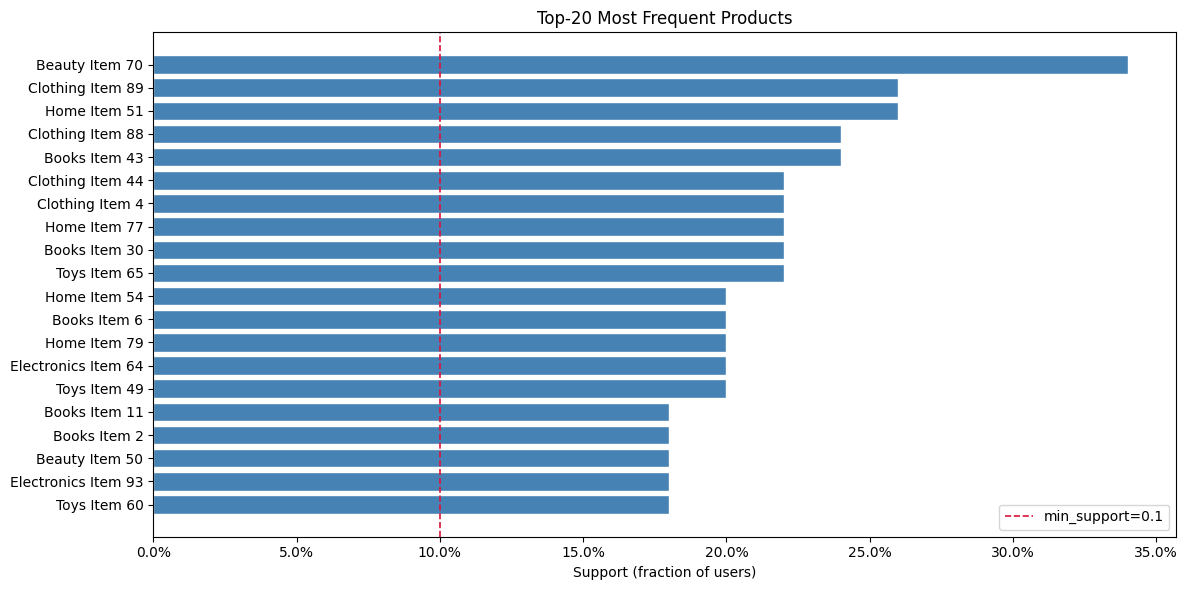

Saved frequent itemsets chart to visuals\frequent_itemsets_barchart.png


In [51]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

VIS_DIR = Path("visuals")
VIS_DIR.mkdir(exist_ok=True)

TOP_N = 20

single_itemsets = cast(pd.DataFrame, frequent_itemsets[frequent_itemsets["length"] == 1])
single_itemsets_sorted = cast(pd.DataFrame, pd.DataFrame.sort_values(cast(pd.DataFrame, single_itemsets), by=["support"], ascending=False))
top_singles = cast(pd.DataFrame, single_itemsets_sorted.head(TOP_N).copy())
top_singles["label"] = [list(x)[0] for x in top_singles["itemsets"]]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(
    list(top_singles["label"])[::-1],
    list(top_singles["support"])[::-1],
    color="steelblue", edgecolor="white",
)
ax.axvline(MIN_SUPPORT, color="crimson", linestyle="--", linewidth=1.2, label=f"min_support={MIN_SUPPORT}")
ax.set_xlabel("Support (fraction of users)")
ax.set_title(f"Top-{TOP_N} Most Frequent Products")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
frequent_itemsets_chart_path = VIS_DIR / "frequent_itemsets_barchart.png"
plt.savefig(frequent_itemsets_chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved frequent itemsets chart to {frequent_itemsets_chart_path}")

## 6. Visualise association rules: scatter plot

Each point represents one rule. The X-axis shows support (how common the product pair is), the Y-axis shows confidence (how reliably one product predicts the other), and the colour shows lift (how much stronger the association is compared to chance). Rules in the top-right corner with warm colours are the most valuable: common, reliable, and non-obvious.

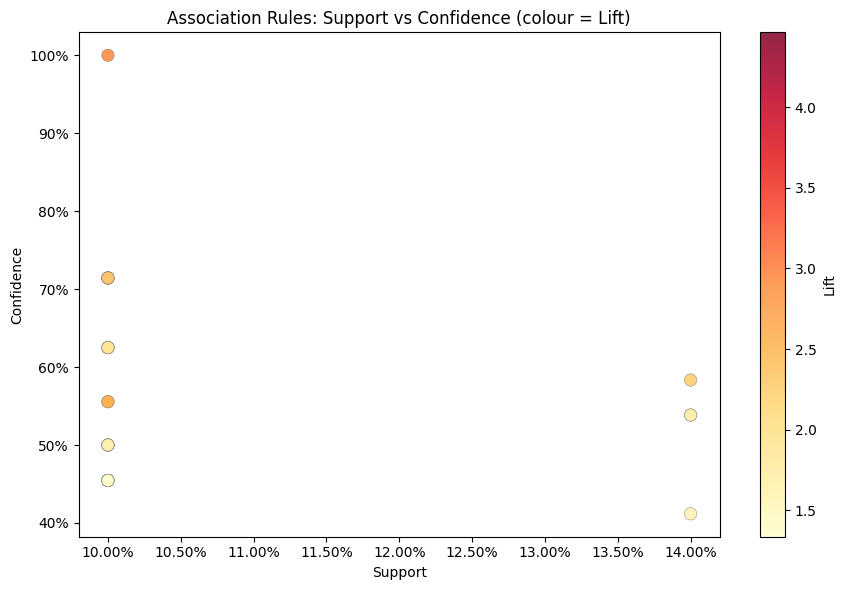

Saved association rules scatter plot to visuals\association_rules_scatter.png


In [52]:
if len(rules) == 0:
    print("No rules to plot — try lowering MIN_CONFIDENCE or MIN_SUPPORT.")
else:
    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(
        rules["support"],
        rules["confidence"],
        c=rules["lift"],
        cmap="YlOrRd",
        s=80,
        alpha=0.85,
        edgecolors="grey",
        linewidths=0.4,
    )
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Lift")
    ax.set_xlabel("Support")
    ax.set_ylabel("Confidence")
    ax.set_title("Association Rules: Support vs Confidence (colour = Lift)")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.tight_layout()
    association_rules_scatter_path = VIS_DIR / "association_rules_scatter.png"
    plt.savefig(association_rules_scatter_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved association rules scatter plot to {association_rules_scatter_path}")

## 7. Visualise association rules: top rules bar chart

Each bar is one rule shown as **Antecedent -> Consequent**. Bar length represents lift (how much stronger the association is compared to random chance). Colour represents confidence (green = high, red = low). Support and confidence values are annotated on each bar.

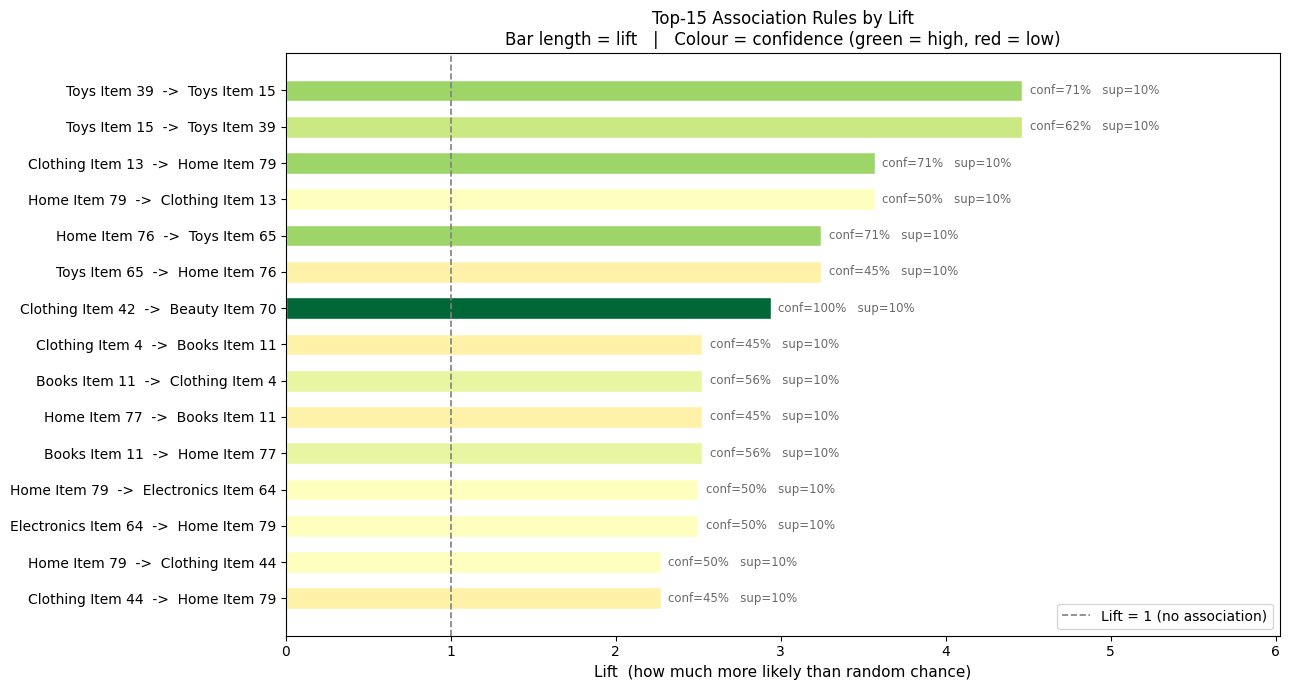

Saved association rules bar chart to visuals\association_rules_barchart.png


In [53]:
if len(rules) == 0:
    print("No rules to plot.")
else:
    TOP_RULES = 15
    top_rules = cast(pd.DataFrame, rules.head(TOP_RULES).copy())
    top_rules["label"] = [
        f"{', '.join(sorted(ants))}  ->  {', '.join(sorted(cons))}"
        for ants, cons in zip(top_rules["antecedents"], top_rules["consequents"])
    ]

    # Map confidence to a green-to-red colour scale
    cmap = plt.get_cmap("RdYlGn")
    colors = [cmap(c) for c in top_rules["confidence"].values]

    fig, ax = plt.subplots(figsize=(13, 7))
    bars = ax.barh(
        list(top_rules["label"])[::-1],
        list(top_rules["lift"])[::-1],
        color=colors[::-1],
        edgecolor="white",
        height=0.6,
    )

    # Annotate each bar with confidence and support
    max_lift = top_rules["lift"].max()
    for i, (_, row) in enumerate(list(top_rules.iterrows())[::-1]):
        ax.text(
            row["lift"] + max_lift * 0.01,
            i,
            f"conf={row['confidence']:.0%}   sup={row['support']:.0%}",
            va="center", fontsize=8.5, color="dimgray",
        )

    ax.axvline(1.0, color="gray", linestyle="--", linewidth=1.2, label="Lift = 1 (no association)")
    ax.set_xlabel("Lift  (how much more likely than random chance)", fontsize=11)
    ax.set_xlim(0, max_lift * 1.35)
    ax.set_title(
        f"Top-{TOP_RULES} Association Rules by Lift\n"
        "Bar length = lift   |   Colour = confidence (green = high, red = low)",
        fontsize=12,
    )
    ax.legend(fontsize=10)
    plt.tight_layout()
    association_rules_barchart_path = VIS_DIR / "association_rules_barchart.png"
    plt.savefig(association_rules_barchart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved association rules bar chart to {association_rules_barchart_path}")

## 8. Export rules to CSV

Save the full rules table to `association_rules.csv` for use in reporting or downstream analysis.

In [54]:
rules_export = cast(pd.DataFrame, rules.copy())
rules_export["antecedents"] = [", ".join(sorted(x)) for x in rules_export["antecedents"]]
rules_export["consequents"] = [", ".join(sorted(x)) for x in rules_export["consequents"]]
rules_export.to_csv("association_rules.csv", index=False)
print("Saved association_rules.csv")
display(rules_export[["antecedents", "consequents", "support", "confidence", "lift"]].head(20))

Saved association_rules.csv


,antecedents,consequents,support,confidence,lift
0,Toys Item 39,Toys Item 15,0.10,0.714286,4.464286
1,Toys Item 15,Toys Item 39,0.10,0.625000,4.464286
2,Clothing Item 13,Home Item 79,0.10,0.714286,3.571429
3,Home Item 79,Clothing Item 13,0.10,0.500000,3.571429
4,Home Item 76,Toys Item 65,0.10,0.714286,3.246753
5,Toys Item 65,Home Item 76,0.10,0.454545,3.246753
6,Clothing Item 42,Beauty Item 70,0.10,1.000000,2.941176
7,Clothing Item 4,Books Item 11,0.10,0.454545,2.525253
8,Books Item 11,Clothing Item 4,0.10,0.555556,2.525253
9,Home Item 77,Books Item 11,0.10,0.454545,2.525253


# SmartCart: Part 4 - Analysis & Visualization

This section turns the recommendation outputs into presentation-ready visuals. It includes a **user similarity heatmap** and **top-5 recommendations for each user group**, which are both required in the assignment.

## 1. User similarity heatmap

To keep the chart readable, the heatmap focuses on the **15 most active users** (users with the most interactions). This makes it easier to spot clusters of similar shoppers.

Heatmap similarity range (off-diagonal): min=0.0000, max=0.4983


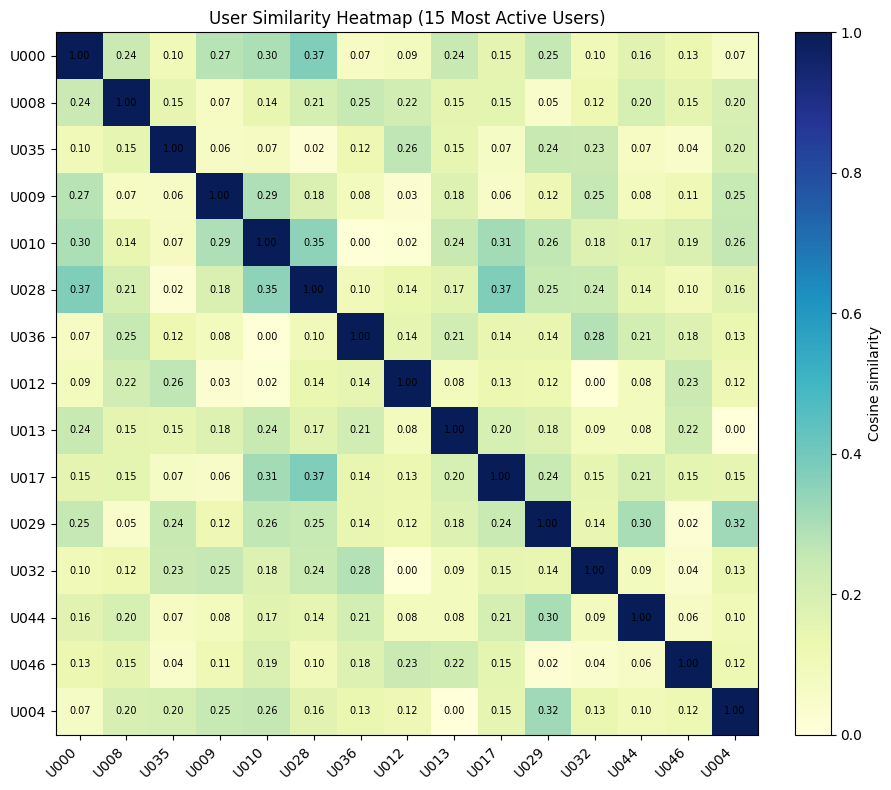

Saved heatmap to visuals\user_similarity_heatmap.png


In [55]:
import matplotlib.pyplot as plt

VIS_DIR = Path("visuals")
VIS_DIR.mkdir(exist_ok=True)

heatmap_similarity_matrix = cosine_similarity(user_item_matrix_filled.astype(float).to_numpy())
heatmap_similarity_df = cast(
    pd.DataFrame,
    pd.DataFrame(
        heatmap_similarity_matrix,
        index=user_item_matrix_filled.index,
        columns=user_item_matrix_filled.index,
    ),
)
off_diag_mask = ~np.eye(len(heatmap_similarity_df), dtype=bool)
off_diag_values = heatmap_similarity_df.to_numpy()[off_diag_mask]
if bool(np.allclose(off_diag_values, 1.0)):
    raise AssertionError("Heatmap similarity matrix is all ones off-diagonal; check the user-item matrix build.")
print(
    f"Heatmap similarity range (off-diagonal): min={off_diag_values.min():.4f}, max={off_diag_values.max():.4f}"
)

active_user_counts = cast(pd.Series, user_merged.groupby("UserID").size())
top_active_users = cast(
    list[str],
    [user_id for user_id, _ in sorted(active_user_counts.items(), key=lambda x: x[1], reverse=True)[:15]],
)
similarity_view = heatmap_similarity_df.loc[top_active_users, top_active_users]
display_similarity = similarity_view.copy()

fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.get_cmap("YlGnBu")
im = ax.imshow(display_similarity.to_numpy(), cmap=cmap, vmin=0, vmax=1)
tick_positions = list(range(len(top_active_users)))
ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)
ax.set_xticklabels(top_active_users, rotation=45, ha="right")
ax.set_yticklabels(top_active_users)
ax.set_title("User Similarity Heatmap (15 Most Active Users)")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Cosine similarity")

for i in range(len(top_active_users)):
    for j in range(len(top_active_users)):
        ax.text(j, i, f"{similarity_view.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
heatmap_path = VIS_DIR / "user_similarity_heatmap.png"
plt.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved heatmap to {heatmap_path}")

## 2. Top-5 recommendations for each user group

Users are grouped by their **dominant category**: the category they interact with most often. For each group, recommendation scores are aggregated across all users in that group, and the highest-ranked products are shown as the group's top-5 recommendations.

In [56]:
user_group_summary_base = cast(
    pd.DataFrame,
    user_merged.groupby(["UserID", "Category"])
    .agg(Interactions=("ProductID", "count"), AvgRating=("Rating", "mean"))
    .reset_index(),
)
user_group_summary_sorted = cast(
    pd.DataFrame,
    pd.DataFrame.sort_values(
        user_group_summary_base,
        by=["UserID", "Interactions", "AvgRating"],
        ascending=[True, False, False],
    ),
)
user_group_summary = cast(
    pd.DataFrame,
    user_group_summary_sorted.drop_duplicates(subset=["UserID"], keep="first").rename(columns={"Category": "UserGroup"}),
)

user_to_group = user_group_summary.set_index("UserID")["UserGroup"]
product_name_map = product_data.set_index("ProductID")["ProductName"]

per_user_recommendations = []
for user_id in R.index:
    ranked = recommend_user_based(
        user_id,
        R,
        similarity_df,
        user_means,
        item_popularity_scores,
        n_neighbors=BEST_NEIGHBORS,
        top_n=5,
        min_neighbor_rating=BEST_MIN_NEIGHBOR_RATING,
        pop_weight=BEST_POP_WEIGHT,
    )
    for rank, (product_id, score) in enumerate(ranked.items(), start=1):
        per_user_recommendations.append(
            {
                "UserID": user_id,
                "UserGroup": user_to_group.get(user_id, "Other"),
                "ProductID": product_id,
                "ProductName": product_name_map.get(product_id, product_id),
                "Score": float(score),
                "Rank": rank,
            }
        )

group_recommendations_raw = pd.DataFrame(per_user_recommendations)
group_top5_base = cast(
    pd.DataFrame,
    group_recommendations_raw.groupby(["UserGroup", "ProductID", "ProductName"], as_index=False)
    .agg(TotalScore=("Score", "sum"), RecommenderCount=("UserID", "count"), MeanRank=("Rank", "mean")),
)
group_top5_sorted = cast(
    pd.DataFrame,
    pd.DataFrame.sort_values(
        group_top5_base,
        by=["UserGroup", "TotalScore", "RecommenderCount", "MeanRank"],
        ascending=[True, False, False, True],
    ),
)
group_top5 = cast(pd.DataFrame, group_top5_sorted.groupby("UserGroup", as_index=False).head(5))

group_top5.to_csv(VIS_DIR / "group_top5_recommendations.csv", index=False)
display(group_top5)
print(f"Saved grouped recommendations to {VIS_DIR / 'group_top5_recommendations.csv'}")

,UserGroup,ProductID,ProductName,TotalScore,RecommenderCount,MeanRank
0,Beauty,P0005,Home Item 5,81.422940,6,1.000000
5,Beauty,P0054,Home Item 54,77.019795,6,2.000000
1,Beauty,P0030,Books Item 30,53.719563,6,3.333333
6,Beauty,P0070,Beauty Item 70,44.653171,5,4.000000
2,Beauty,P0043,Books Item 43,25.580416,3,5.000000
9,Books,P0005,Home Item 5,176.416369,13,1.000000
15,Books,P0054,Home Item 54,141.202957,11,1.818182
11,Books,P0043,Books Item 43,110.848470,13,4.153846
10,Books,P0030,Books Item 30,89.532606,10,2.800000
16,Books,P0070,Beauty Item 70,89.306342,10,3.600000


Saved grouped recommendations to visuals\group_top5_recommendations.csv


## 3. Visual summary of group recommendations

The chart below compares the strongest recommended products across user groups using the **aggregated recommendation score**.

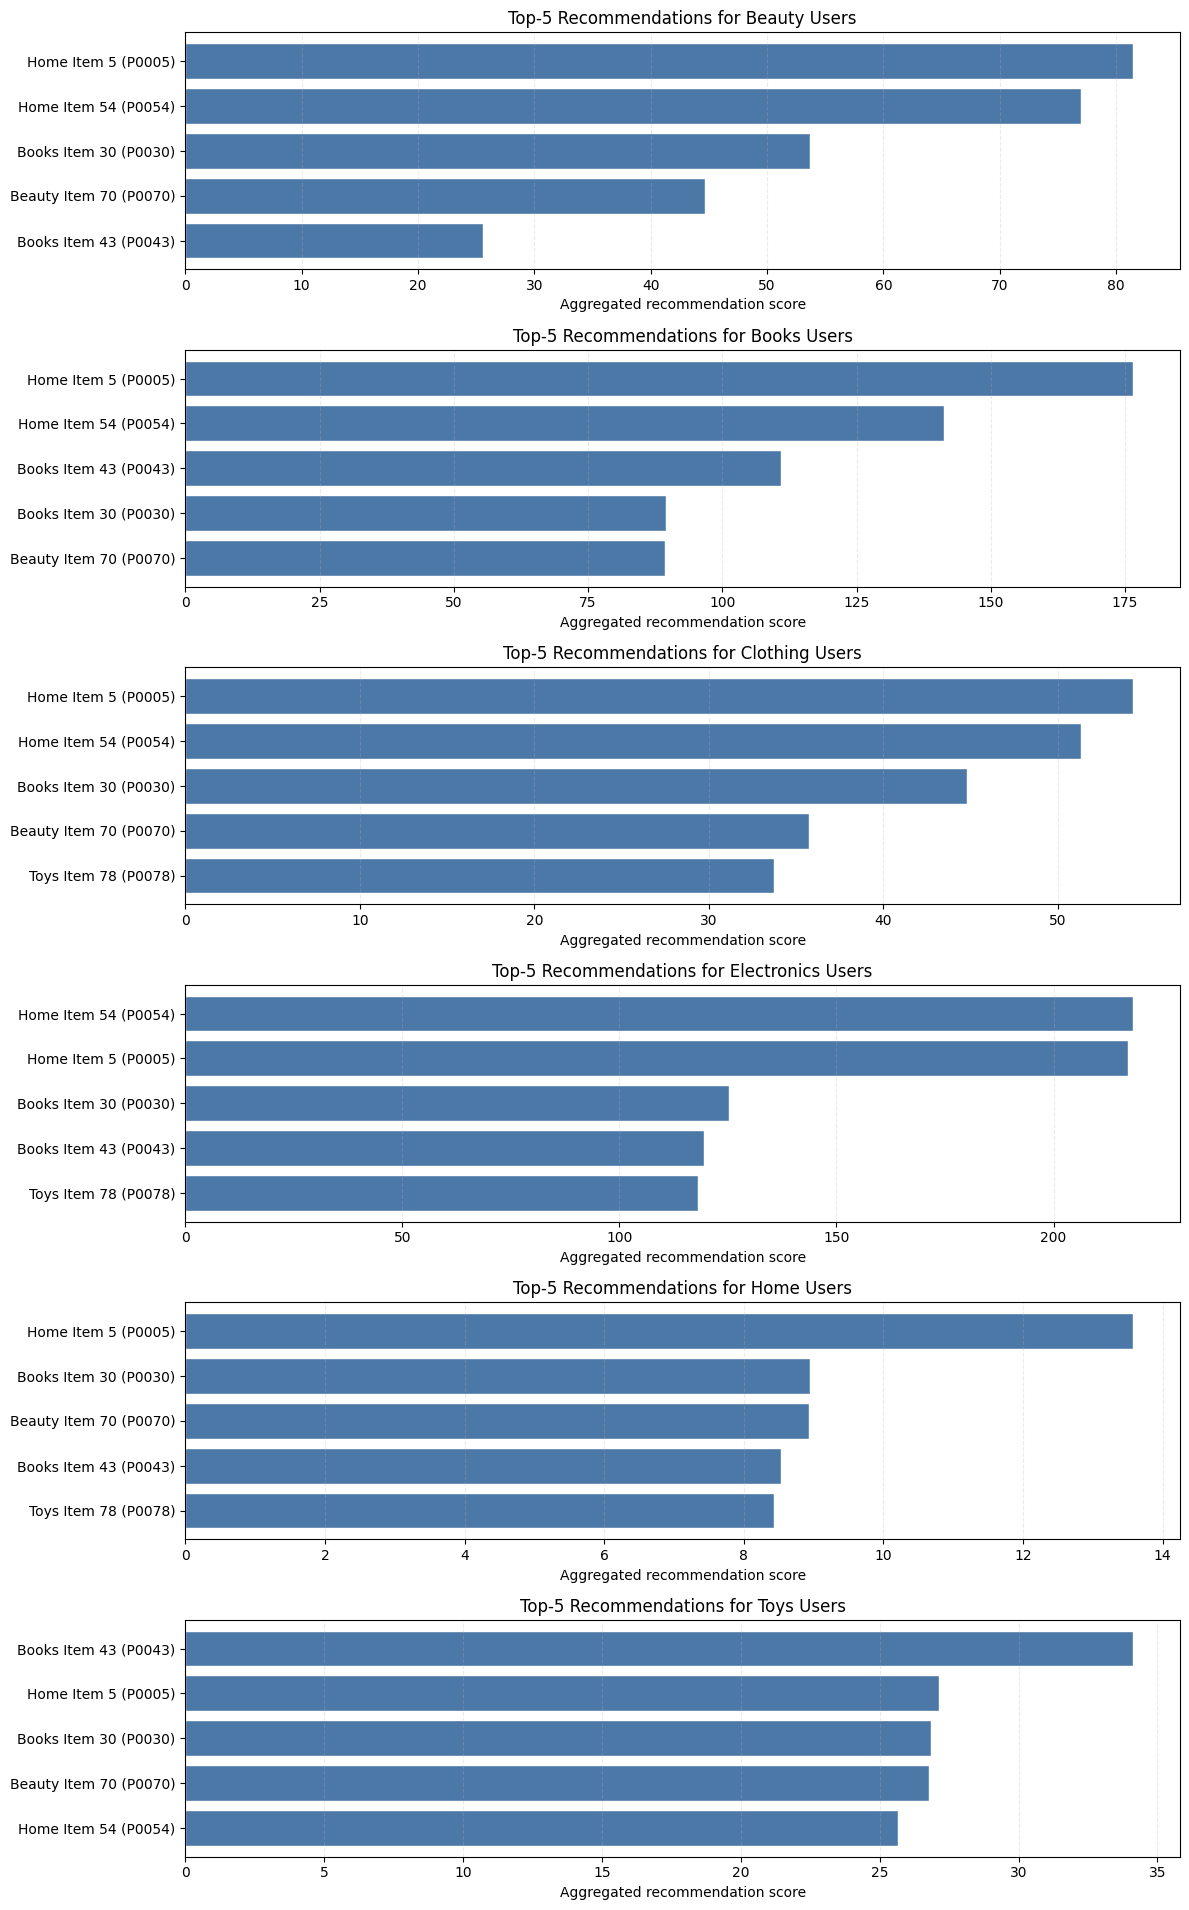

Saved group recommendation chart to visuals\group_top5_recommendations.png


In [57]:
plot_df = group_top5.copy()
plot_df["Label"] = plot_df["ProductName"] + " (" + plot_df["ProductID"] + ")"

groups = cast(list[str], [str(group_name) for group_name in plot_df["UserGroup"].unique().tolist()])
fig, axes = plt.subplots(len(groups), 1, figsize=(12, 3.2 * len(groups)), sharex=False)
if len(groups) == 1:
    axes = [axes]

for ax, group_name in zip(axes, groups):
    grp = cast(
        pd.DataFrame,
        pd.DataFrame.sort_values(
            cast(pd.DataFrame, plot_df[plot_df["UserGroup"] == group_name]),
            by=["TotalScore"],
            ascending=True,
        ),
    )
    ax.barh(grp["Label"], grp["TotalScore"], color="#4C78A8", edgecolor="white")
    ax.set_title(f"Top-5 Recommendations for {group_name} Users")
    ax.set_xlabel("Aggregated recommendation score")
    ax.grid(axis="x", linestyle="--", alpha=0.25)

plt.tight_layout()
group_chart_path = VIS_DIR / "group_top5_recommendations.png"
plt.savefig(group_chart_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved group recommendation chart to {group_chart_path}")